# EDA — Fake Users (Twitter profiles)

**File:** `data/fake_users.csv`

This notebook explores the raw Twitter-style account dataset before building a
fake-account detection model. Rows in this file are **fake** accounts.

The plan:
1. Load and take a first look
2. Missing values
3. Duplicates
4. Numeric feature analysis
5. Categorical / text feature analysis
6. Correlations
7. Comparison with the opposite class (real vs fake)
8. Key observations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

DATA_PATH = "../data/fake_users.csv"
df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]:,}  Columns: {df.shape[1]}")
df.head()

Rows: 2,500  Columns: 34


,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,url,lang,time_zone,location,default_profile,default_profile_image,geo_enabled,profile_image_url,profile_banner_url,profile_use_background_image,profile_background_image_url_https,profile_text_color,profile_image_url_https,profile_sidebar_border_color,profile_background_tile,profile_sidebar_fill_color,profile_background_image_url,profile_background_color,profile_link_color,utc_offset,protected,verified,description,updated,dataset
0,1.664073e+09,Lavona Keller,kellervxg,13.093733,-0.000000,0.000000,0.0,0.0,Sun Jun 24 03:26:11 +0000 2012,-0.0,en,NaN,NaN,2.874910,0.0,0.0,http://a0.twimg.com/profile_images/3310916330/...,NaN,0.000000,https://si0.twimg.com/images/themes/theme1/bg.png,NaN,NaN,C0DEED,0.0,DDEEF6,NaN,C0DEED,NaN,0.0,0.0,0.0,Keep moving forwad,2015-02-14 10:40:01,NaN
1,7.296345e+08,Elizabet Graves,NaN,0.000000,0.000000,0.000000,0.0,0.0,Mon Jun 25 02:06:59 +0000 2012,0.0,en,NaN,"Manhattan, NY",0.000000,-0.0,-0.0,http://a0.twimg.com/profile_images/3192428454/...,NaN,0.000000,https://si0.twimg.com/images/themes/theme1/bg.png,NaN,https://si0.twimg.com/profile_images/319242845...,C0DEED,0.0,DDEEF6,http://a0.twimg.com/images/themes/theme1/bg.png,NaN,0084B4,0.0,0.0,0.0,NaN,2015-02-14 10:40:01,NaN
2,1.214885e+09,Estelle Santos,estellesant,52.941642,-0.000000,518.508286,-0.0,-0.0,Sat Jun 23 19:48:28 +0000 2012,-0.0,en,NaN,NaN,0.000000,-0.0,0.0,http://a0.twimg.com/profile_images/3232367297/...,NaN,0.515751,https://si0.twimg.com/images/themes/theme1/bg.png,333333,NaN,NaN,0.0,NaN,NaN,C0DEED,0084B4,0.0,0.0,0.0,"Practical wisdom,healh, Chinese Medicine",NaN,NaN
3,-0.000000e+00,Patsy Weiss,patsyyor,18.857321,0.000000,1059.138617,0.0,0.0,Sat Jun 23 15:34:23 +0000 2012,0.0,en,NaN,atlanta georgia,2.297083,0.0,-0.0,NaN,NaN,0.000000,https://si0.twimg.com/images/themes/theme1/bg.png,NaN,NaN,C0DEED,0.0,DDEEF6,http://a0.twimg.com/images/themes/theme1/bg.png,C0DEED,0084B4,0.0,0.0,0.0,this is a support page or el_aminito check him...,NaN,INT
4,1.844412e+09,Cindy Cook,NaN,51.167110,7.368223,0.000000,0.0,0.0,NaN,0.0,en,NaN,Worldwide,0.000000,0.0,0.0,http://a0.twimg.com/profile_images/3234284505/...,NaN,0.000000,https://si0.twimg.com/images/themes/theme1/bg.png,NaN,NaN,C0DEED,0.0,DDEEF6,http://a0.twimg.com/images/themes/theme1/bg.png,NaN,NaN,0.0,0.0,-0.0,NaN,NaN,NaN


## 1. First look — structure, dtypes, samples

In [2]:
df.info()
df.sample(5, random_state=42)

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 34 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  2500 non-null   float64
 1   name                                1640 non-null   str    
 2   screen_name                         1579 non-null   str    
 3   statuses_count                      2500 non-null   float64
 4   followers_count                     2500 non-null   float64
 5   friends_count                       2500 non-null   float64
 6   favourites_count                    2500 non-null   float64
 7   listed_count                        2500 non-null   float64
 8   created_at                          1636 non-null   str    
 9   url                                 2500 non-null   float64
 10  lang                                1620 non-null   str    
 11  time_zone                           4 non-null      st

,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,url,lang,time_zone,location,default_profile,default_profile_image,geo_enabled,profile_image_url,profile_banner_url,profile_use_background_image,profile_background_image_url_https,profile_text_color,profile_image_url_https,profile_sidebar_border_color,profile_background_tile,profile_sidebar_fill_color,profile_background_image_url,profile_background_color,profile_link_color,utc_offset,protected,verified,description,updated,dataset
1447,0.000000e+00,Morgan Fox,morganuycr,69.292058,32.904366,110.858733,0.0,-0.0,Sun Jun 24 00:06:55 +0000 2012,-0.0,en,NaN,NaN,0.0,-0.0,0.0,NaN,NaN,0.000000,https://si0.twimg.com/images/themes/theme1/bg.png,333333,NaN,C0DEED,0.0,DDEEF6,http://a0.twimg.com/images/themes/theme1/bg.png,NaN,NaN,0.0,0.0,0.0,NaN,2015-02-14 10:40:01,INT
1114,9.101530e+08,NaN,jeanettequhpr,51.896019,0.000000,0.000000,0.0,0.0,Sat Jun 23 15:43:45 +0000 2012,0.0,en,NaN,Detroit/MI,0.0,0.0,0.0,http://a0.twimg.com/profile_images/3230072307/...,NaN,3.743042,NaN,NaN,https://si0.twimg.com/profile_images/323007230...,C0DEED,0.0,NaN,http://a0.twimg.com/images/themes/theme1/bg.png,NaN,0084B4,0.0,0.0,0.0,NaN,2015-02-14 10:40:01,NaN
1064,-0.000000e+00,Gisele Palmer,palmersukk,49.567221,-0.000000,35.874762,0.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,-0.0,http://a0.twimg.com/profile_images/3287983324/...,NaN,-0.000000,https://si0.twimg.com/images/themes/theme1/bg.png,333333,NaN,C0DEED,-0.0,NaN,NaN,NaN,0084B4,0.0,0.0,0.0,NaN,NaN,NaN
2287,6.092391e+08,Noella Phillips,noellafuh,-0.000000,104.114058,298.506265,-0.0,0.0,Sat Jun 23 22:06:49 +0000 2012,0.0,en,NaN,"Cologne, Germany",0.0,-0.0,-0.0,http://a0.twimg.com/profile_images/3295659068/...,NaN,1.055863,https://si0.twimg.com/images/themes/theme1/bg.png,NaN,https://si0.twimg.com/profile_images/329565906...,C0DEED,0.0,DDEEF6,http://a0.twimg.com/images/themes/theme1/bg.png,C0DEED,0084B4,-0.0,0.0,0.0,NaN,NaN,NaN
1537,0.000000e+00,John Patrick,NaN,77.767840,42.237623,398.391090,0.0,0.0,Sat Jun 23 15:48:24 +0000 2012,0.0,en,NaN,NaN,-0.0,0.0,0.0,NaN,NaN,0.000000,NaN,NaN,https://si0.twimg.com/profile_images/330368406...,NaN,-0.0,DDEEF6,NaN,C0DEED,NaN,-0.0,-0.0,0.0,"ife Sucks, So Grab A Straw And Get Cofortable...",2015-02-14 10:40:01,INT


## 2. Missing values

In [3]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_tbl = (
    pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
    .query("missing_count > 0")
    .sort_values("missing_pct", ascending=False)
)
print(f"Columns with missing values: {len(missing_tbl)} / {df.shape[1]}")
missing_tbl


Columns with missing values: 19 / 34


,missing_count,missing_pct
profile_banner_url,2498,99.92
time_zone,2496,99.84
description,1176,47.04
location,943,37.72
screen_name,921,36.84
updated,907,36.28
profile_background_color,904,36.16
profile_image_url_https,904,36.16
profile_image_url,902,36.08
profile_text_color,888,35.52


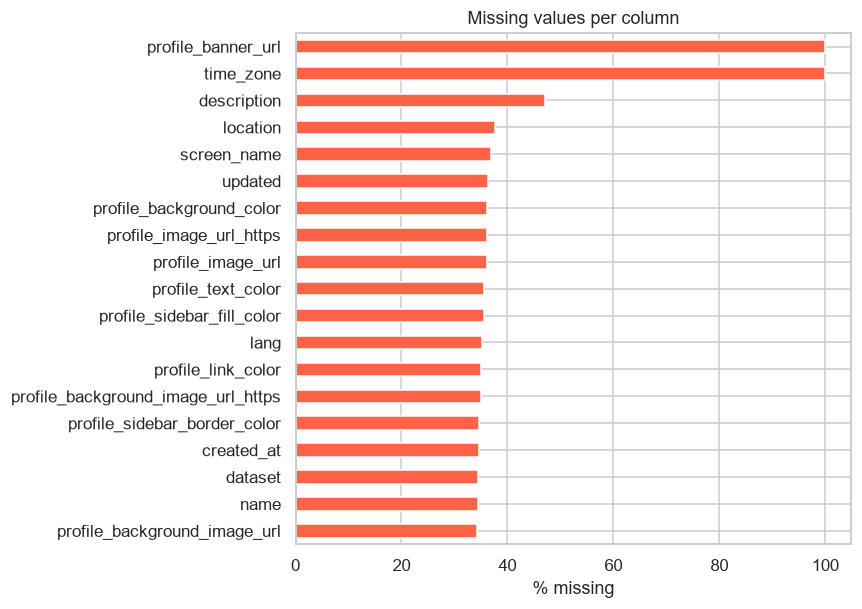

In [4]:
if missing_tbl.empty:
    print("No missing values in this dataset.")
else:
    fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(missing_tbl))))
    missing_tbl["missing_pct"].sort_values().plot.barh(ax=ax, color="tomato")
    ax.set_xlabel("% missing")
    ax.set_title("Missing values per column")
    plt.tight_layout()
    plt.show()


## 3. Duplicates

In [5]:
print(f"Fully duplicated rows: {df.duplicated().sum()}")
if "id" in df.columns:
    print(f"Duplicated 'id' values: {df['id'].duplicated().sum()}")
    print("Most frequent ids:")
    display(df["id"].value_counts().head(10))


Fully duplicated rows: 0
Duplicated 'id' values: 1282
Most frequent ids:


id
-0.000000e+00    1283
 1.664073e+09       1
 7.296345e+08       1
 1.214885e+09       1
 1.844412e+09       1
 1.275418e+09       1
 9.201496e+08       1
 6.612017e+08       1
 1.021070e+09       1
 6.267733e+08       1
Name: count, dtype: int64

## 4. Numeric feature analysis

Note: numeric columns include fields that should be counts or booleans
(`followers_count`, `default_profile`, ...). Their continuous / fractional values
indicate the data has been obfuscated or noise-added.

In [6]:
num_cols = df.select_dtypes(include="number").columns.tolist()
print(f"Numeric columns ({len(num_cols)}):")
display(df[num_cols].describe().T.round(3))


Numeric columns (15):


,count,mean,std,min,25%,50%,75%,max
id,2500.0,5.489711e+08,8.437555e+08,0.0,0.0,0.0,9.121206e+08,6.535702e+09
statuses_count,2500.0,3.469700e+01,1.419970e+02,0.0,0.0,0.0,4.862200e+01,5.663665e+03
followers_count,2500.0,1.315900e+01,2.111700e+01,0.0,0.0,0.0,2.193100e+01,1.646510e+02
friends_count,2500.0,3.009750e+02,4.922030e+02,0.0,0.0,0.0,4.816840e+02,3.541657e+03
favourites_count,2500.0,8.407000e+00,1.427960e+02,0.0,0.0,0.0,0.000000e+00,4.415483e+03
listed_count,2500.0,3.000000e-03,8.400000e-02,0.0,-0.0,0.0,0.000000e+00,3.320000e+00
url,2500.0,0.000000e+00,0.000000e+00,-0.0,0.0,0.0,0.000000e+00,-0.000000e+00
default_profile,2500.0,7.840000e-01,1.120000e+00,-0.0,-0.0,0.0,1.384000e+00,7.095000e+00
default_profile_image,2500.0,3.000000e-03,7.300000e-02,0.0,0.0,0.0,0.000000e+00,2.245000e+00
geo_enabled,2500.0,1.000000e-03,3.300000e-02,0.0,0.0,0.0,0.000000e+00,1.671000e+00


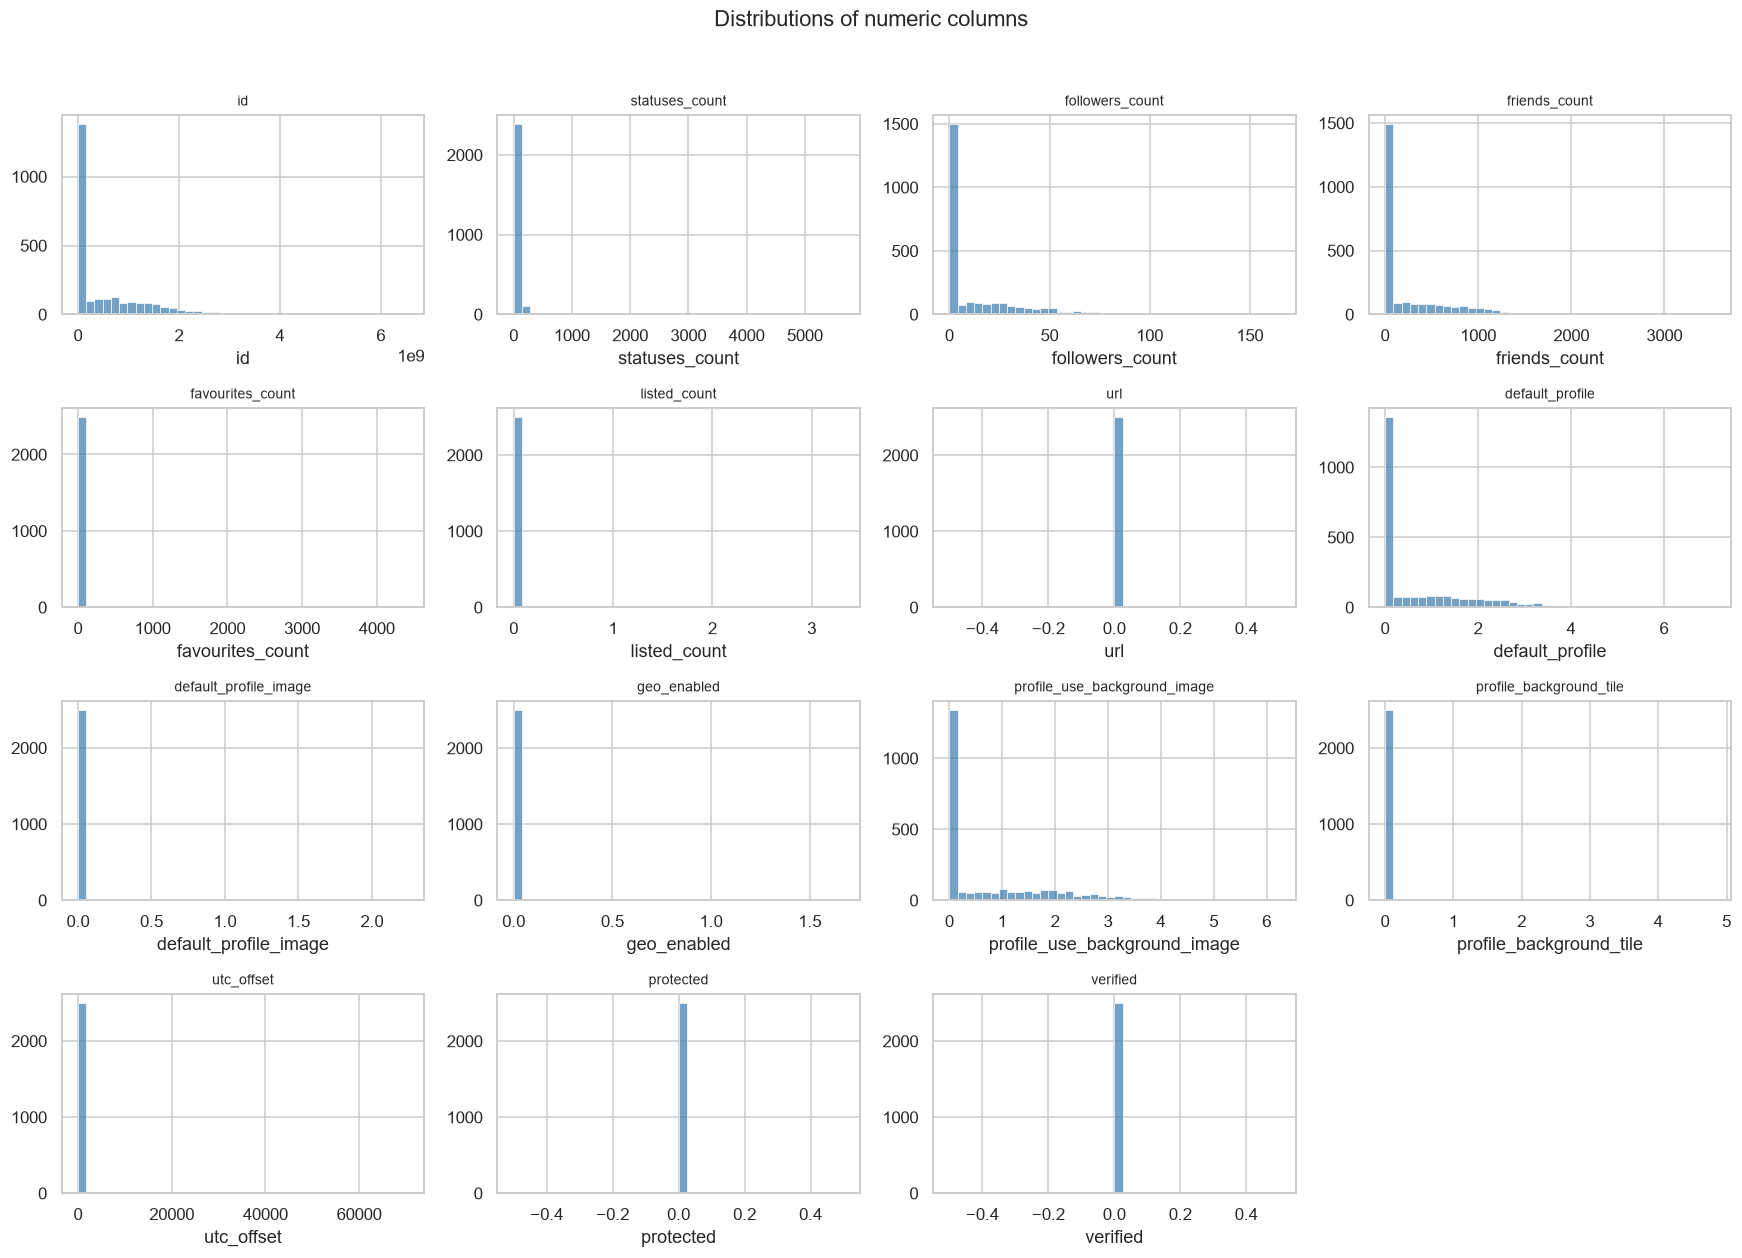

In [7]:
n = len(num_cols)
ncols = min(n, 4)
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 2.8 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), bins=40, ax=ax, color="steelblue")
    ax.set_title(col, fontsize=9)
    ax.set_ylabel("")
for ax in axes[n:]:
    ax.axis("off")
plt.suptitle("Distributions of numeric columns", y=1.02)
plt.tight_layout()
plt.show()


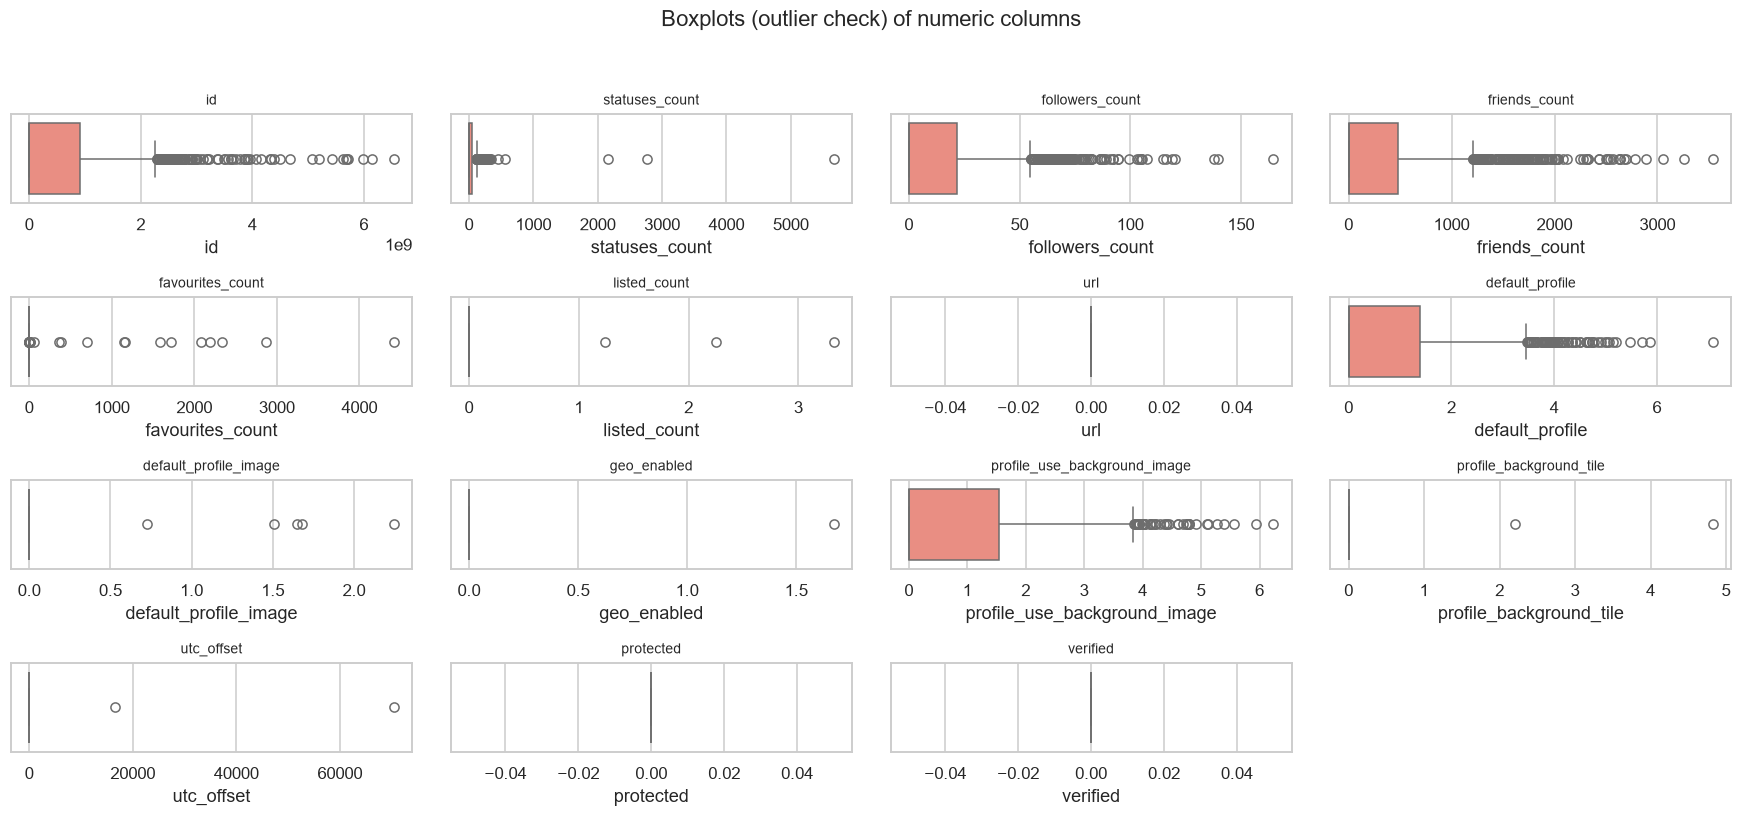

In [8]:
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 1.8 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col].dropna(), ax=ax, color="salmon")
    ax.set_title(col, fontsize=9)
    ax.set_yticks([])
for ax in axes[n:]:
    ax.axis("off")
plt.suptitle("Boxplots (outlier check) of numeric columns", y=1.03)
plt.tight_layout()
plt.show()


## 5. Categorical / text features

In [9]:
cat_cols = [c for c in df.columns if c not in num_cols]
print(f"Non-numeric columns ({len(cat_cols)}):")
overview = pd.DataFrame({
    "nunique": [df[c].nunique(dropna=True) for c in cat_cols],
    "missing_pct": [round(df[c].isna().mean() * 100, 1) for c in cat_cols],
    "example": [str(df[c].dropna().iloc[0])[:60] if df[c].notna().any() else "-" for c in cat_cols],
}, index=cat_cols)
display(overview)


Non-numeric columns (19):


,nunique,missing_pct,example
name,957,34.4,Lavona Keller
screen_name,939,36.8,kellervxg
created_at,919,34.6,Sun Jun 24 03:26:11 +0000 2012
lang,1,35.2,en
time_zone,3,99.8,Hawaii
location,768,37.7,"Manhattan, NY"
profile_image_url,944,36.1,http://a0.twimg.com/profile_images/3310916330/...
profile_banner_url,1,99.9,https://twimg0-a.akamaihd.net/profile_banners/...
profile_background_image_url_https,7,35.0,https://si0.twimg.com/images/themes/theme1/bg.png
profile_text_color,3,35.5,333333


Low-cardinality categorical columns: ['time_zone', 'profile_background_image_url_https', 'profile_text_color', 'profile_sidebar_border_color', 'profile_sidebar_fill_color', 'profile_background_image_url', 'profile_background_color', 'profile_link_color']


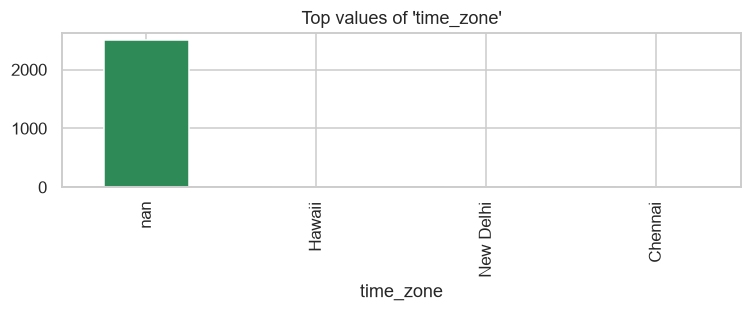

C:\Users\Acer\AppData\Local\Temp\ipykernel_3916\2928573287.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


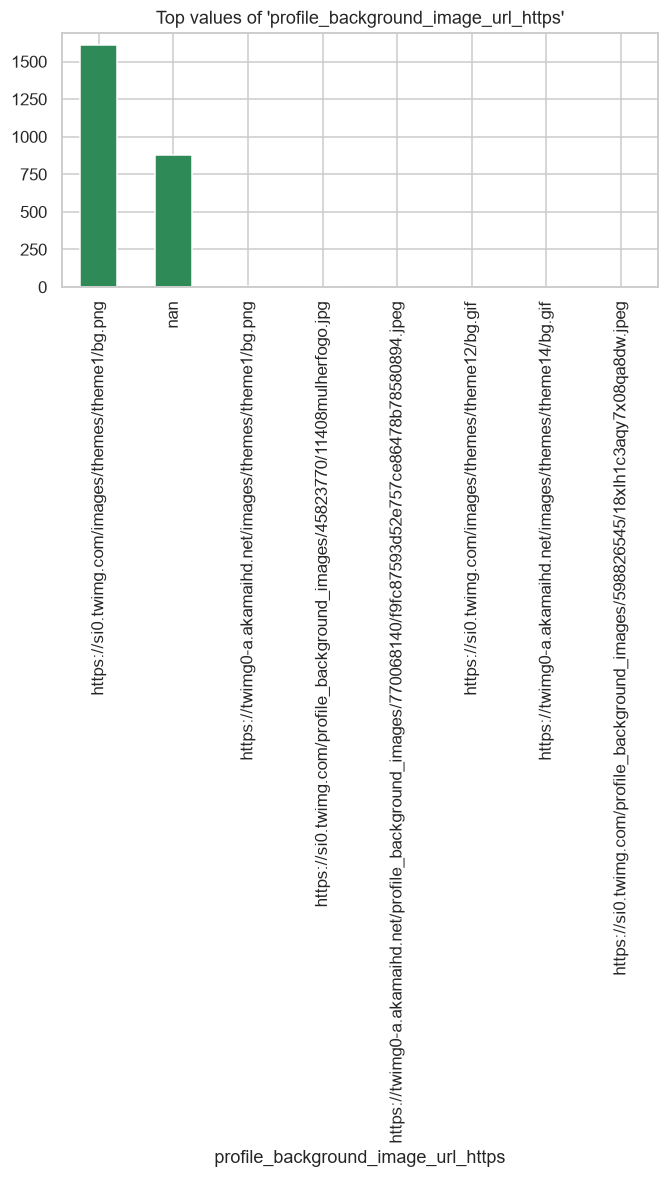

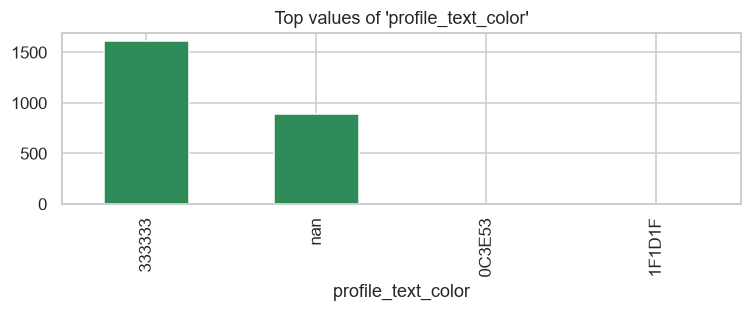

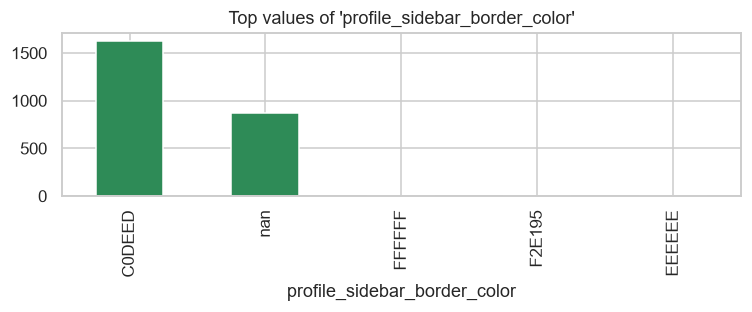

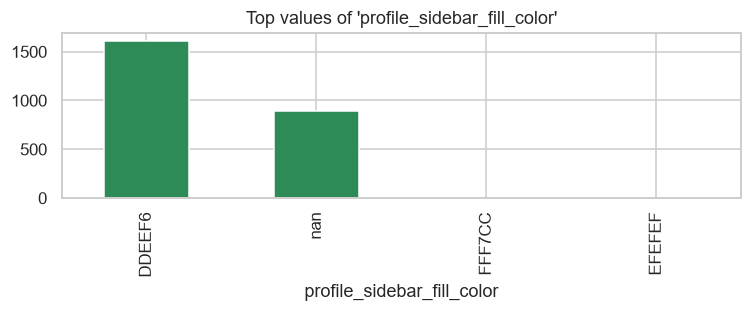

C:\Users\Acer\AppData\Local\Temp\ipykernel_3916\2928573287.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


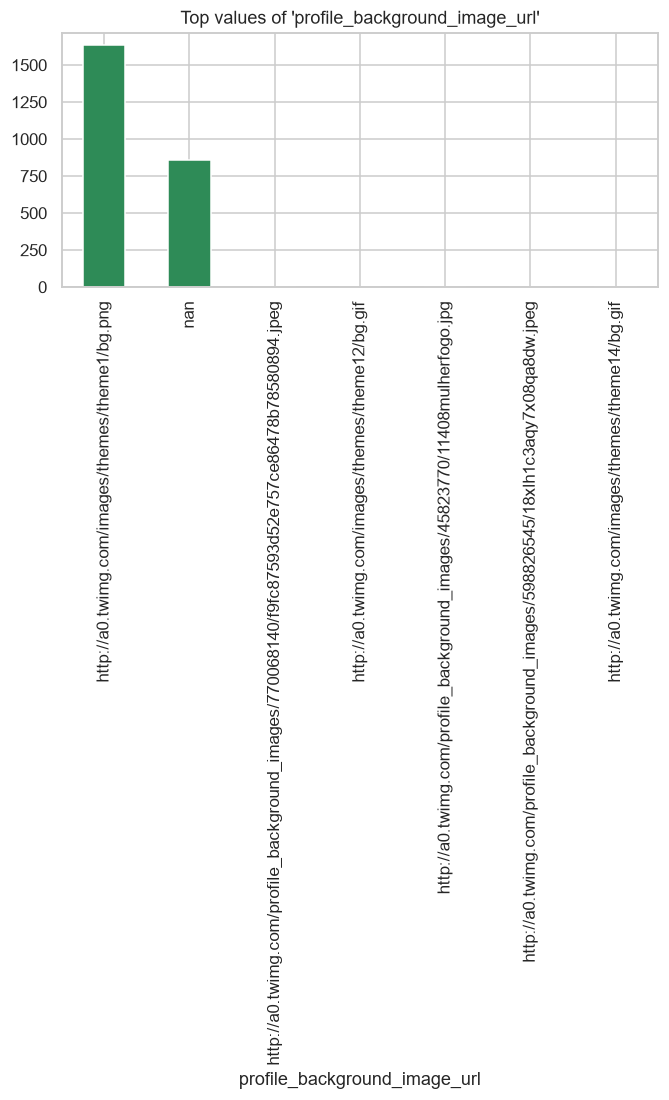

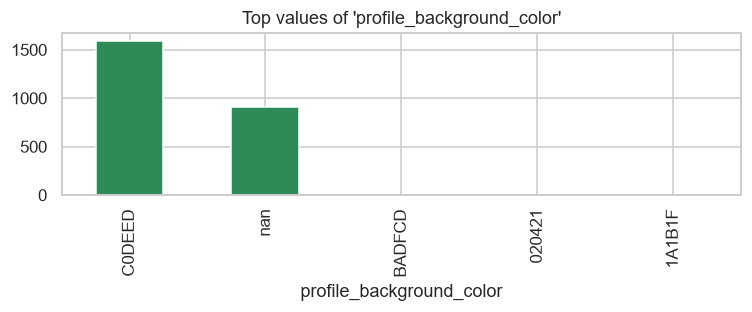

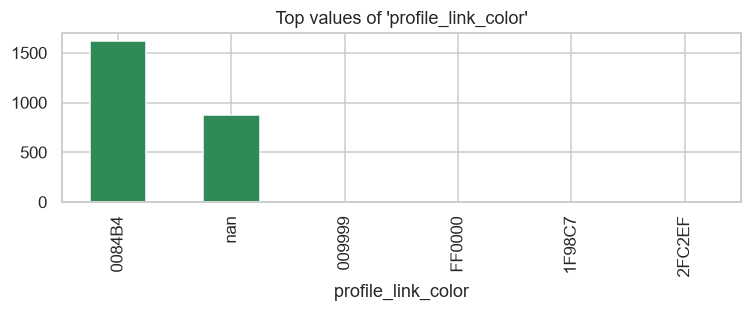

In [10]:
# Top values for the most informative low-cardinality categorical columns
low_card = [c for c in cat_cols if 1 < df[c].nunique(dropna=True) <= 30]
print("Low-cardinality categorical columns:", low_card)
for c in low_card[:8]:
    fig, ax = plt.subplots(figsize=(7, 3))
    df[c].value_counts(dropna=False).head(15).plot.bar(ax=ax, color="seagreen")
    ax.set_title(f"Top values of '{c}'")
    plt.tight_layout()
    plt.show()


## 5b. Account creation dates

`created_at` is parsed to see when accounts were created — bursty creation
periods are a classic fake-account signal.

Parseable created_at values: 1636 / 2500
Year range: 2009.0 - 2013.0


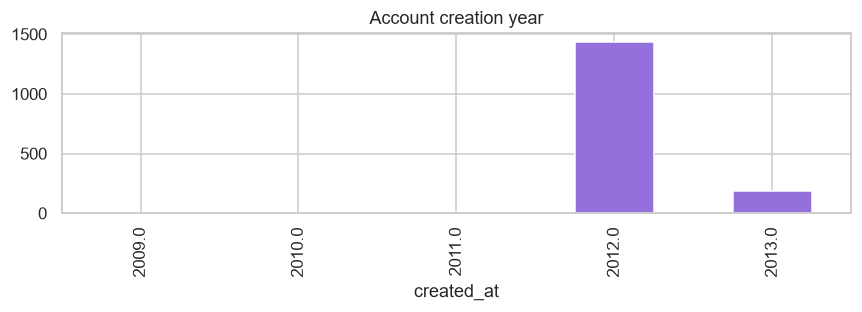

In [11]:
created = pd.to_datetime(df["created_at"], format="%a %b %d %H:%M:%S %z %Y", errors="coerce")
print(f"Parseable created_at values: {created.notna().sum()} / {len(df)}")
print(f"Year range: {created.dt.year.min()} - {created.dt.year.max()}")
fig, ax = plt.subplots(figsize=(8, 3))
created.dt.year.value_counts().sort_index().plot.bar(ax=ax, color="mediumpurple")
ax.set_title("Account creation year")
plt.tight_layout()
plt.show()

## 6. Correlations

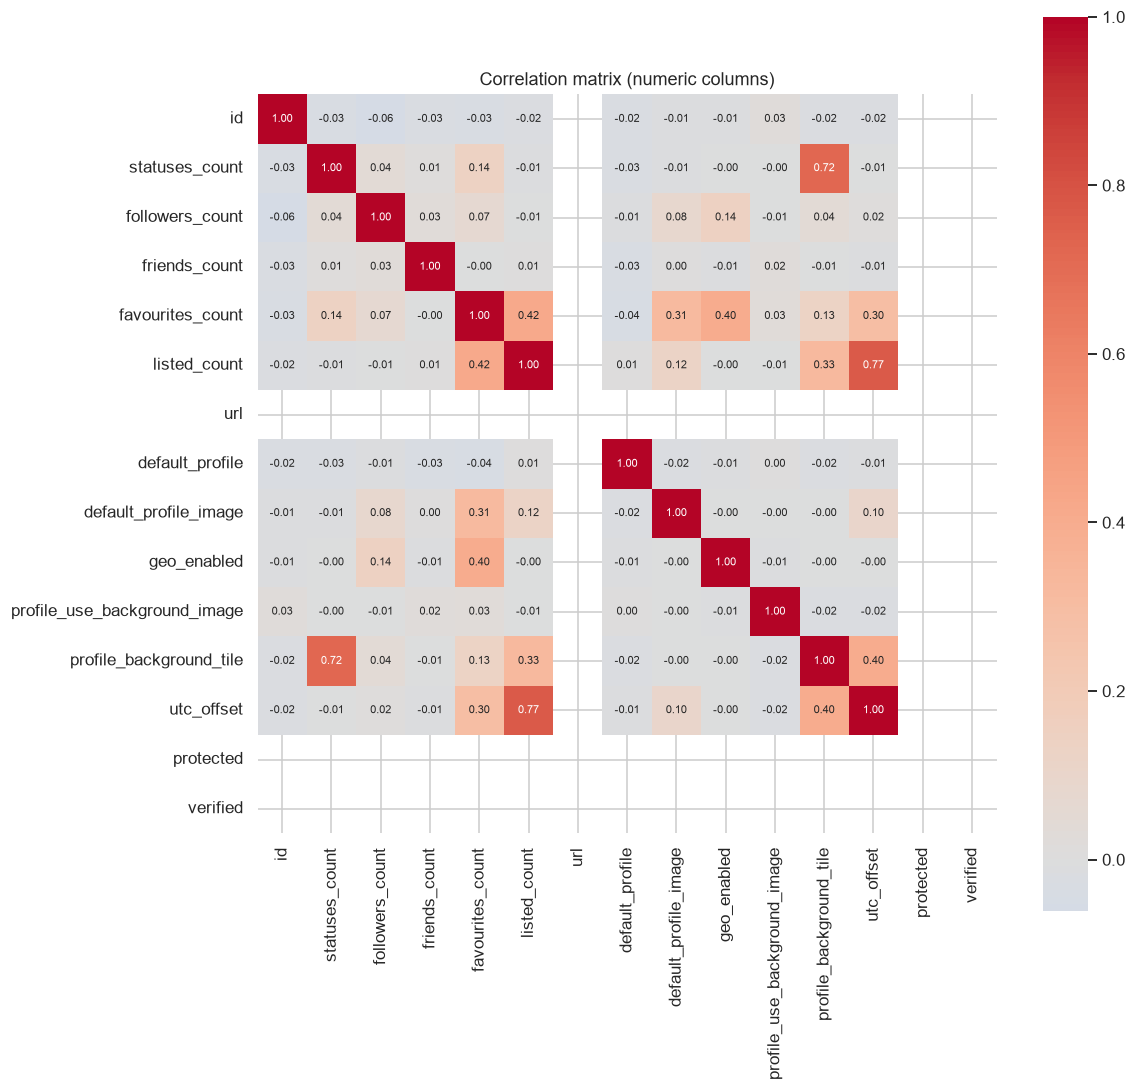

In [12]:
corr = df[num_cols].corr(numeric_only=True)
plt.figure(figsize=(min(14, 0.6 * len(num_cols) + 2), min(12, 0.55 * len(num_cols) + 2)))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=len(num_cols) <= 18,
            fmt=".2f", annot_kws={"size": 7}, square=True)
plt.title("Correlation matrix (numeric columns)")
plt.tight_layout()
plt.show()


## 7. Comparison with the opposite class

This file only contains **fake** accounts, so we load the complementary
file to compare class-level statistics — this tells us which features are likely
to be discriminative for the model.

In [13]:
other_file = "fake_users.csv" if "real" in DATA_PATH else "real_users.csv"
df_other = pd.read_csv("../data/" + other_file)
print(f"Compared against: {other_file}  ({df_other.shape[0]} rows)")
# keep only columns that are numeric in BOTH files (column dtypes can differ between files)
shared_num = [c for c in num_cols if pd.api.types.is_numeric_dtype(df_other[c])]
means_this = df[shared_num].mean(numeric_only=True)
means_other = df_other[shared_num].mean(numeric_only=True)
comparison = pd.DataFrame({
    "this": means_this,
    "other": means_other,
    "ratio": means_this / means_other.replace(0, np.nan),
}).round(3).sort_values("ratio")
display(comparison)

Compared against: real_users.csv  (2500 rows)


,this,other,ratio
listed_count,3.000000e-03,4.247000e+00,0.001
geo_enabled,1.000000e-03,3.580000e-01,0.002
profile_background_tile,3.000000e-03,2.540000e-01,0.011
statuses_count,3.469700e+01,2.592901e+03,0.013
utc_offset,3.481200e+01,2.240324e+03,0.016
followers_count,1.315900e+01,6.306720e+02,0.021
favourites_count,8.407000e+00,3.578190e+02,0.023
friends_count,3.009750e+02,3.297410e+02,0.913
profile_use_background_image,8.230000e-01,7.470000e-01,1.101
id,5.489711e+08,3.265032e+08,1.681


## 8. Key observations
- **2,500 rows x 34 columns**, same schema as `real_users.csv` (rows here are fake accounts).
- **Heavy missingness** (~35%) overall, and **near-total missingness for fakes** on `time_zone` (99.8%), `profile_banner_url` (99.9%), `url` — much stronger than in the real class, a very discriminative signal.
- **No fully duplicated rows**, ~51% duplicated `id` values (again dominated by `0.0`).
- **Numeric values obfuscated/noised** exactly like the real file (fractional booleans, `-0.0`); `protected` and `verified` all 0.
- Distinct "fake follower" profile shape vs real users: mean **statuses_count only ~35** (vs ~2,593 real), mean **followers ~13** (vs ~630), mean favourites ~8 (vs ~358), `listed_count` almost always 0 — i.e. fake accounts follow many but tweet/engage little.
- Creation dates span 2006–2015.
- **Modeling implications:** the follower/friends vs statuses/favourites asymmetry plus missingness of profile metadata are the strongest discriminative features; same preprocessing caveats as the real file.